SET UP

In [89]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [90]:
import warnings
import logging
import os
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

In [91]:
!pip install -Uqq fastai
!pip install ddgs

In [92]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [93]:
from ddgs import DDGS
from fastcore.all import *

def search_images(keywords, max_images=150): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json

In [94]:
urls = search_images('Buildings', max_images=1)
urls[0]

'https://media.architecturaldigest.com/photos/5e3d873df7884d0008fde3db/master/w_1600,c_limit/GettyImages-1062914940.jpg'

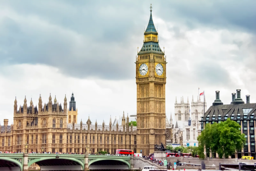

In [95]:
from fastdownload import download_url
dest = 'building.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

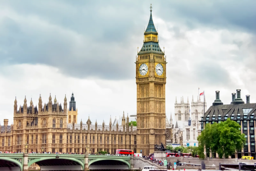

In [96]:
download_url(search_images('buildings', max_images =1)[0], 'building.jpg', show_progress=False)
Image.open('building.jpg').to_thumb(256,256)

In [98]:
searches = 'gothic', 'art deco', 'modernist', 'classical'
path = Path('Type_of_Architecture')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

TRAINING MODEL

In [99]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

1

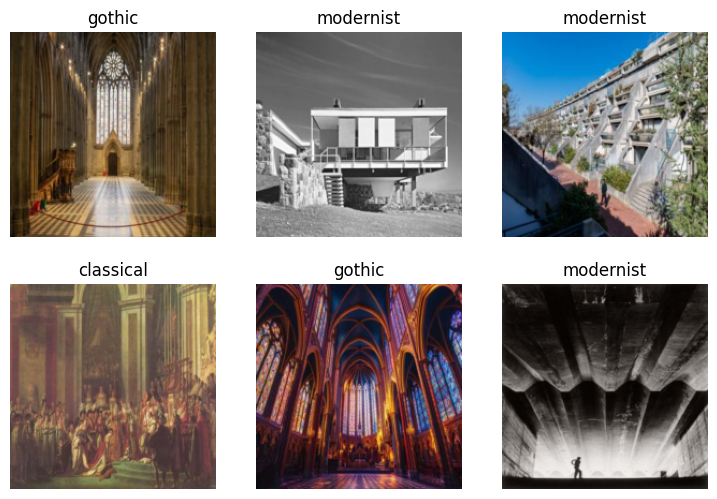

In [100]:
dls = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct=0.2, seed=42),
    get_y = parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs = 32)

dls.show_batch(max_n=6)

In [ ]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.354714,0.155621,0.067039,00:56


epoch,train_loss,valid_loss,error_rate,time


In [ ]:
building_architecture_style,_,probs = learn.predict(PILImage.create('building.jpg'))
print(f"This building is built using {building_architecture_style}. ")
print(f"Probability its built using style: {probs[0]:.4f}")